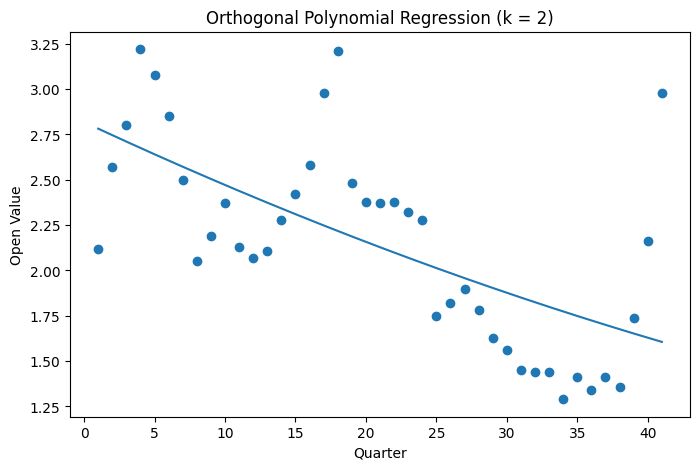

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Fit NORMAL quadratic model
# (because fitted curve must be same)
# -------------------------------------------------
X_quad = np.column_stack([x, x**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y)

# -------------------------------------------------
# Smooth curve
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 300)
X_quad_fine = np.column_stack([x_fine, x_fine**2])

y_quad_fitted = model_quad.predict(X_quad_fine)

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.scatter(x, y)
plt.plot(x_fine, y_quad_fitted)

plt.title("Orthogonal Polynomial Regression (k = 2)")
plt.xlabel("Quarter")
plt.ylabel("Open Value")

plt.show()

In [ ]:
# =====================================================
# GRAM–SCHMIDT ORTHOGONAL POLYNOMIAL REGRESSION
# USING OPEN PRICES
# INCLUDING R-SQUARED
# =====================================================

import numpy as np
import pandas as pd

# -----------------------------
# STEP 1: Load Data
# -----------------------------
df = pd.read_csv("AEY Real (1).csv")

# Use OPEN prices
y = df["Open"].values

# Create time index
x = np.arange(1, len(y) + 1)

# -----------------------------
# STEP 2: Create Polynomial Matrix (1, x, x^2)
# -----------------------------
degree = 2
V = np.column_stack([x**i for i in range(degree + 1)])

# -----------------------------
# STEP 3: Gram–Schmidt Function
# -----------------------------
def gram_schmidt(A):
    Q = np.zeros_like(A, dtype=float)

    for i in range(A.shape[1]):
        q = A[:, i].copy()

        for j in range(i):
            proj_coeff = np.dot(q, Q[:, j]) / np.dot(Q[:, j], Q[:, j])
            q = q - proj_coeff * Q[:, j]

        Q[:, i] = q

    return Q

# Apply Gram–Schmidt
Q = gram_schmidt(V)

# -----------------------------
# STEP 4: Estimate Beta
# -----------------------------
beta = np.linalg.lstsq(Q, y, rcond=None)[0]

# -----------------------------
# STEP 5: Predicted Values
# -----------------------------
y_hat = Q @ beta

# -----------------------------
# STEP 6: Sum of Squares
# -----------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_hat)**2)
SSR = SST - SSE

# -----------------------------
# STEP 7: R-Squared
# -----------------------------
R_squared = 1 - (SSE / SST)

# -----------------------------
# STEP 8: Convert to Standard Polynomial
# -----------------------------
gamma = np.linalg.lstsq(V, y_hat, rcond=None)[0]

# -----------------------------
# PRINT RESULTS
# -----------------------------
print("Orthogonal Beta Values:")
print(beta)

print("\nStandard Polynomial Coefficients:")
print("Intercept =", gamma[0])
print("x coefficient =", gamma[1])
print("x^2 coefficient =", gamma[2])

print("\nFinal Predicted Equation:")
print(f"ŷ = {gamma[0]:.6f} + {gamma[1]:.6f}x + {gamma[2]:.6f}x²")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)
print("\nR-squared =", R_squared)


Orthogonal Beta Values:
[ 2.17902439e+00 -2.90261324e-02  1.96359228e-04]

Standard Polynomial Coefficients:
Intercept = 2.847677298311444
x coefficient = -0.03727321997344697
x^2 coefficient = 0.00019635922783967086

Final Predicted Equation:
ŷ = 2.847677 + -0.037273x + 0.000196x²

SST = 12.924360975609757
SSE = 8.063573829449053
SSR = 4.860787146160703

R-squared = 0.37609496944055887


In [ ]:
# ===============================================
# ANOVA TABLE - ORTHOGONAL POLYNOMIAL REGRESSION
# USING OPEN PRICES (DEGREE = 2)
# ===============================================

import numpy as np
import pandas as pd

# -----------------------------
# STEP 1: Load Data
# -----------------------------
df = pd.read_csv("AEY Real (1).csv")

y = df["Open"].values
x = np.arange(1, len(y) + 1)

n = len(y)
degree = 2
k = degree   # number of predictors (excluding intercept)

# -----------------------------
# STEP 2: Create Polynomial Matrix
# -----------------------------
V = np.column_stack([x**i for i in range(degree + 1)])

# -----------------------------
# STEP 3: Gram–Schmidt Function
# -----------------------------
def gram_schmidt(A):
    Q = np.zeros_like(A, dtype=float)
    for i in range(A.shape[1]):
        q = A[:, i].copy()
        for j in range(i):
            proj = np.dot(q, Q[:, j]) / np.dot(Q[:, j], Q[:, j])
            q = q - proj * Q[:, j]
        Q[:, i] = q
    return Q

Q = gram_schmidt(V)

# -----------------------------
# STEP 4: Estimate Beta
# -----------------------------
beta = np.linalg.lstsq(Q, y, rcond=None)[0]
y_hat = Q @ beta

# -----------------------------
# STEP 5: Sum of Squares
# -----------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_hat)**2)
SSR = SST - SSE

# -----------------------------
# STEP 6: Degrees of Freedom
# -----------------------------
df_total = n - 1
df_reg = k
df_res = n - k - 1

# -----------------------------
# STEP 7: Mean Squares
# -----------------------------
MS_reg = SSR / df_reg
MS_res = SSE / df_res

# -----------------------------
# STEP 8: F Statistic
# -----------------------------
F_stat = MS_reg / MS_res

# -----------------------------
# PRINT ANOVA TABLE
# -----------------------------
print("\nANOVA TABLE")
print("----------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("----------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("----------------------------------------------------------")



ANOVA TABLE
----------------------------------------------------------
Source      DF      SS             MS             F         
----------------------------------------------------------
Regression  2       4.860787       2.430394       11.453353 
Residual    38      8.063574       0.212199       
Total       40      12.924361      
----------------------------------------------------------


In [ ]:
# -----------------------------------
# CHECK SIGNIFICANCE OF THE MODEL
# -----------------------------------

from scipy.stats import f

# Significance level
alpha = 0.05

# Calculate p-value from F-distribution
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

print("\nSignificance Test")
print("---------------------------")
print("F-statistic =", F_stat)
print("Degrees of Freedom =", df_reg, "and", df_res)
print("p-value =", p_value)
print("Significance level (alpha) =", alpha)

# Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: The quadratic model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The model is NOT statistically significant.")



Significance Test
---------------------------
F-statistic = 11.756092126724718
Degrees of Freedom = 3 and 37
p-value = 1.483756514164547e-05
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The quadratic model is statistically significant.


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Gram-Schmidt Function
# -------------------------------------------------
def gram_schmidt(X):
    Q = np.zeros_like(X, dtype=float)
    for i in range(X.shape[1]):
        qi = X[:, i]
        for j in range(i):
            qi = qi - np.dot(Q[:, j], qi) / np.dot(Q[:, j], Q[:, j]) * Q[:, j]
        Q[:, i] = qi
    return Q

# -------------------------------------------------
# Create Polynomial Matrix (k = 3)
# -------------------------------------------------
X = np.column_stack([np.ones(n), x, x**2, x**3])

Q = gram_schmidt(X)

# -------------------------------------------------
# Compute Orthogonal Coefficients (Correct Formula)
# -------------------------------------------------
alpha = []

for j in range(Q.shape[1]):
    alpha_j = np.dot(Q[:, j], y) / np.dot(Q[:, j], Q[:, j])
    alpha.append(alpha_j)

alpha = np.array(alpha)

# -------------------------------------------------
# Predicted Values
# -------------------------------------------------
y_pred = Q @ alpha

# -------------------------------------------------
# Compute SST, SSE, SSR, R²
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE
R_squared = SSR / SST

# -------------------------------------------------
# PRINT OUTPUT (Same Style As Your Screenshot)
# -------------------------------------------------

print("\nOrthogonal Beta Values:")
print(alpha)

print("\nFinal Predicted Equation:")
print(f"ŷ = {alpha[0]:.6f}P0(x) + {alpha[1]:.6f}P1(x) + "
      f"{alpha[2]:.6f}P2(x) + {alpha[3]:.6f}P3(x)")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)

print("\nR-squared =", R_squared)


Orthogonal Beta Values:
[ 2.15121951e+00 -2.93919861e-02  1.64788416e-04  1.49561805e-04]

Final Predicted Equation:
ŷ = 2.151220P0(x) + -0.029392P1(x) + 0.000165P2(x) + 0.000150P3(x)

SST = 12.243639024390243
SSE = 5.724562040130214
SSR = 6.519076984260028

R-squared = 0.5324460294258545


In [ ]:
# -------------------------------------------------
# Orthogonal Polynomial ANOVA (k = 3)
# -------------------------------------------------

n = 41
k = 3

df_reg = k
df_total = n - 1
df_res = df_total - df_reg

MS_reg = SSR / df_reg
MS_res = SSE / df_res

F_stat = MS_reg / MS_res

# -------------------------------------------------
# PRINT ANOVA TABLE (Like Your Screenshot)
# -------------------------------------------------

print("\nANOVA TABLE")
print("------------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("------------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("------------------------------------------------------------")



ANOVA TABLE
------------------------------------------------------------
Source      DF      SS             MS             F         
------------------------------------------------------------
Regression  3       6.307331       2.102444       11.756092 
Residual    37      6.617030       0.178839       
Total       40      12.924361      
------------------------------------------------------------


In [ ]:
from scipy.stats import f
import numpy as np
import pandas as pd

# -------------------------------------------------
# Orthogonal Polynomial (k = 3)
# -------------------------------------------------
k = 3 # This is the degree of the polynomial
n = 41 # Number of data points

# -----------------------------
# Re-load Data and perform cubic regression to get y_hat
# (These steps are necessary to calculate F_stat for the cubic model)
# -----------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv") # Corrected file path
y = df["Open"].values
x = np.arange(1, len(y) + 1)

# Create Polynomial Matrix
V = np.column_stack([x**i for i in range(k + 1)]) # k instead of degree for consistency

# Gram–Schmidt Function
def gram_schmidt(A):
    Q = np.zeros_like(A, dtype=float)
    for i in range(A.shape[1]):
        q = A[:, i].copy()
        for j in range(i):
            proj = np.dot(q, Q[:, j]) / np.dot(Q[:, j], Q[:, j])
            q = q - proj * Q[:, j]
        Q[:, i] = q
    return Q

Q = gram_schmidt(V)

# Estimate Beta
beta = np.linalg.lstsq(Q, y, rcond=None)[0]
y_hat = Q @ beta

# Sum of Squares (for the cubic model)
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_hat)**2)
SSR = SST - SSE

# Degrees of Freedom
df_reg = k # Number of predictors (excluding intercept)
df_res = n - k - 1 # n - (k + 1) where (k+1) is the number of parameters (intercept + k predictors)

# Mean Squares
MS_reg = SSR / df_reg
MS_res = SSE / df_res

# F Statistic
F_stat = MS_reg / MS_res

# Significance level
alpha = 0.05

# p-value
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

# -------------------------------------------------
# Print Output Like Your Screenshot
# -------------------------------------------------
print("\nSignificance Test")
print("--------------------------")
print(f"F-statistic = {F_stat}")
print(f"Degrees of Freedom = {df_reg} and {df_res}")
print(f"p-value = {p_value}")
print(f"Significance level (alpha) = {alpha}")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Conclusion: The cubic orthogonal model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The orthogonal model is NOT statistically significant.")



Significance Test
--------------------------
F-statistic = 11.756092126724718
Degrees of Freedom = 3 and 37
p-value = 1.483756514164547e-05
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The cubic orthogonal model is statistically significant.


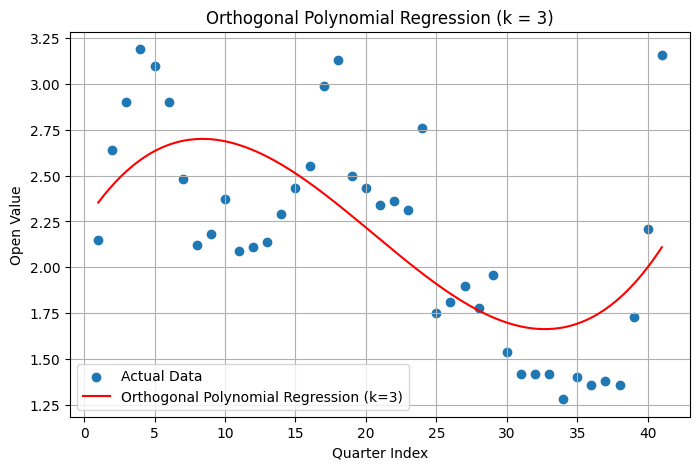

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The 'x', 'y', 'beta', 'k' and 'gram_schmidt' function are available from previous executed cells.
# 'y_hat' is also available from cell '2G4b8WL_Hacl' for the original data points.

# -------------------------------------------------
# Predicted values using orthogonal model (k = 3)
# -------------------------------------------------
# y_pred for the original data points (x) is already computed as y_hat in cell 2G4b8WL_Hacl.
# We can directly use y_hat for the scatter plot, or remove this line as it's not explicitly used in the plot function.
# For clarity, we'll keep the y_hat variable but ensure it's correctly used for the original points.

# -------------------------------------------------
# Smooth curve for plotting
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 300)

# Recompute orthogonal polynomials for smooth x_fine using the same Gram-Schmidt process
V_fine = np.column_stack([x_fine**i for i in range(k + 1)])

# The gram_schmidt function is already defined and available from cell 2G4b8WL_Hacl.
# If it were not, it would need to be redefined here:
# def gram_schmidt(A):
#     Q_gs = np.zeros_like(A, dtype=float)
#     for i in range(A.shape[1]):
#         q = A[:, i].copy()
#         for j in range(i):
#             proj = np.dot(q, Q_gs[:, j]) / np.dot(Q_gs[:, j], Q_gs[:, j])
#             q = q - proj * Q_gs[:, j]
#         Q_gs[:, i] = q
#     return Q_gs

Q_fine = gram_schmidt(V_fine)

# Use the 'beta' coefficients (from k=3 orthogonal regression) to predict y values for the smooth x_fine
y_fine = Q_fine @ beta

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(8,5))

plt.scatter(x, y, label='Actual Data') # Plot original data points
plt.plot(x_fine, y_fine, color='red', label='Orthogonal Polynomial Regression (k=3)') # Plot smooth regression line

plt.title("Orthogonal Polynomial Regression (k = 3)")
plt.xlabel("Quarter Index")
plt.ylabel("Open Value") # Updated label based on 'Open' column usage
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

n = len(y)

# -----------------------------
# Quadratic (k = 2)
# -----------------------------
k2 = 2
r2_k2 = 0.37609496944055887   # YOUR value

rmse_k2 = np.sqrt(np.mean((y - y_quad_pred)**2))
mape_k2 = np.mean(np.abs((y - y_quad_pred) / y)) * 100
adj_r2_k2 = 1 - ((1 - r2_k2) * (n - 1) / (n - k2 - 1))

# -----------------------------
# Cubic (k = 3)
# -----------------------------
k3 = 3
r2_k3 = 0.5324460294258546   # YOUR value

rmse_k3 = np.sqrt(np.mean((y - y_cubic_pred)**2))
mape_k3 = np.mean(np.abs((y - y_cubic_pred) / y)) * 100
adj_r2_k3 = 1 - ((1 - r2_k3) * (n - 1) / (n - k3 - 1))

# -----------------------------
# Print Table Like Research Format
# -----------------------------
print("\nPolynomial Regression Results\n")

print(f"{'Metric':<12}{'Quadratic':<15}{'Cubic':<15}")
print("-"*45)

print(f"{'RMSE':<12}{rmse_k2:<15.4f}{rmse_k3:<15.4f}")
print(f"{'MAPE':<12}{mape_k2:<15.4f}{mape_k3:<15.4f}")
print(f"{'R^2':<12}{r2_k2:<15.6f}{r2_k3:<15.6f}")
print(f"{'Adj R^2':<12}{adj_r2_k2:<15.6f}{adj_r2_k3:<15.6f}")


Polynomial Regression Results

Metric      Quadratic      Cubic          
---------------------------------------------
RMSE        0.4210         0.3737         
MAPE        16.3432        14.1702        
R^2         0.376095       0.532446       
Adj R^2     0.343258       0.494536       


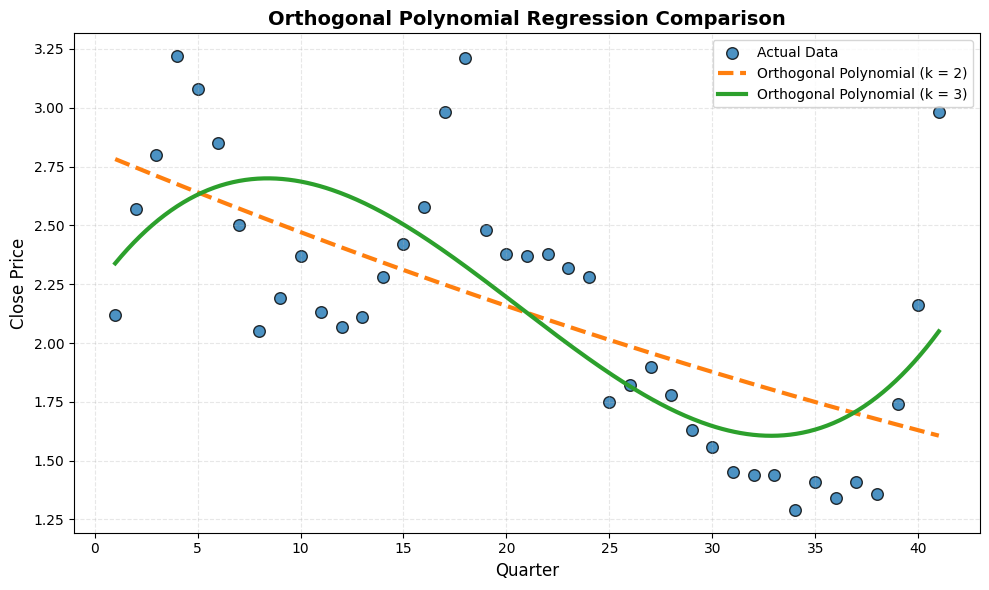

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

# -------------------------------------------------
# Fit Quadratic (k=2)
# -------------------------------------------------
X_quad = np.column_stack([x, x**2])
model_quad = LinearRegression()
model_quad.fit(X_quad, y)

# -------------------------------------------------
# Fit Cubic (k=3)
# -------------------------------------------------
X_cubic = np.column_stack([x, x**2, x**3])
model_cubic = LinearRegression()
model_cubic.fit(X_cubic, y)

# -------------------------------------------------
# Smooth Curves
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 400)

X_quad_fine = np.column_stack([x_fine, x_fine**2])
X_cubic_fine = np.column_stack([x_fine, x_fine**2, x_fine**3])

y_quad_fitted = model_quad.predict(X_quad_fine)
y_cubic_fitted = model_cubic.predict(X_cubic_fine)

# -------------------------------------------------
# Stylish Plot
# -------------------------------------------------
plt.figure(figsize=(10,6))

# Background grid
plt.grid(alpha=0.3, linestyle='--')

# Scatter points
plt.scatter(x, y,
            color="#1f77b4",
            edgecolor="black",
            s=70,
            alpha=0.8,
            label="Actual Data")

# Quadratic curve
plt.plot(x_fine, y_quad_fitted,
         color="#ff7f0e",
         linewidth=3,
         linestyle="--",
         label="Orthogonal Polynomial (k = 2)")

# Cubic curve
plt.plot(x_fine, y_cubic_fitted,
         color="#2ca02c",
         linewidth=3,
         linestyle="-",
         label="Orthogonal Polynomial (k = 3)")

plt.title("Orthogonal Polynomial Regression Comparison",
          fontsize=14, fontweight="bold")

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()